In [1]:
import math
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from group_sae.utils import load_cluster_map

### Parameters

In [2]:
K = 3
size = "1b"
model_name = f"pythia-{size}"
base_folder = f"/root/group-sae/concordance/{model_name}"
g_hats = {"pythia-160m": 6, "pythia-1b": 6, "pythia-410m": 9}


Blocks for K=1: [(0, 15)]
Blocks for K=2: [(0, 9), (9, 15)]
Blocks for K=3: [(0, 5), (5, 9), (9, 15)]
Blocks for K=4: [(0, 5), (5, 9), (9, 13), (13, 15)]
Blocks for K=5: [(0, 2), (2, 5), (5, 9), (9, 13), (13, 15)]
Blocks for K=6: [(0, 2), (2, 5), (5, 9), (9, 11), (11, 13), (13, 15)]


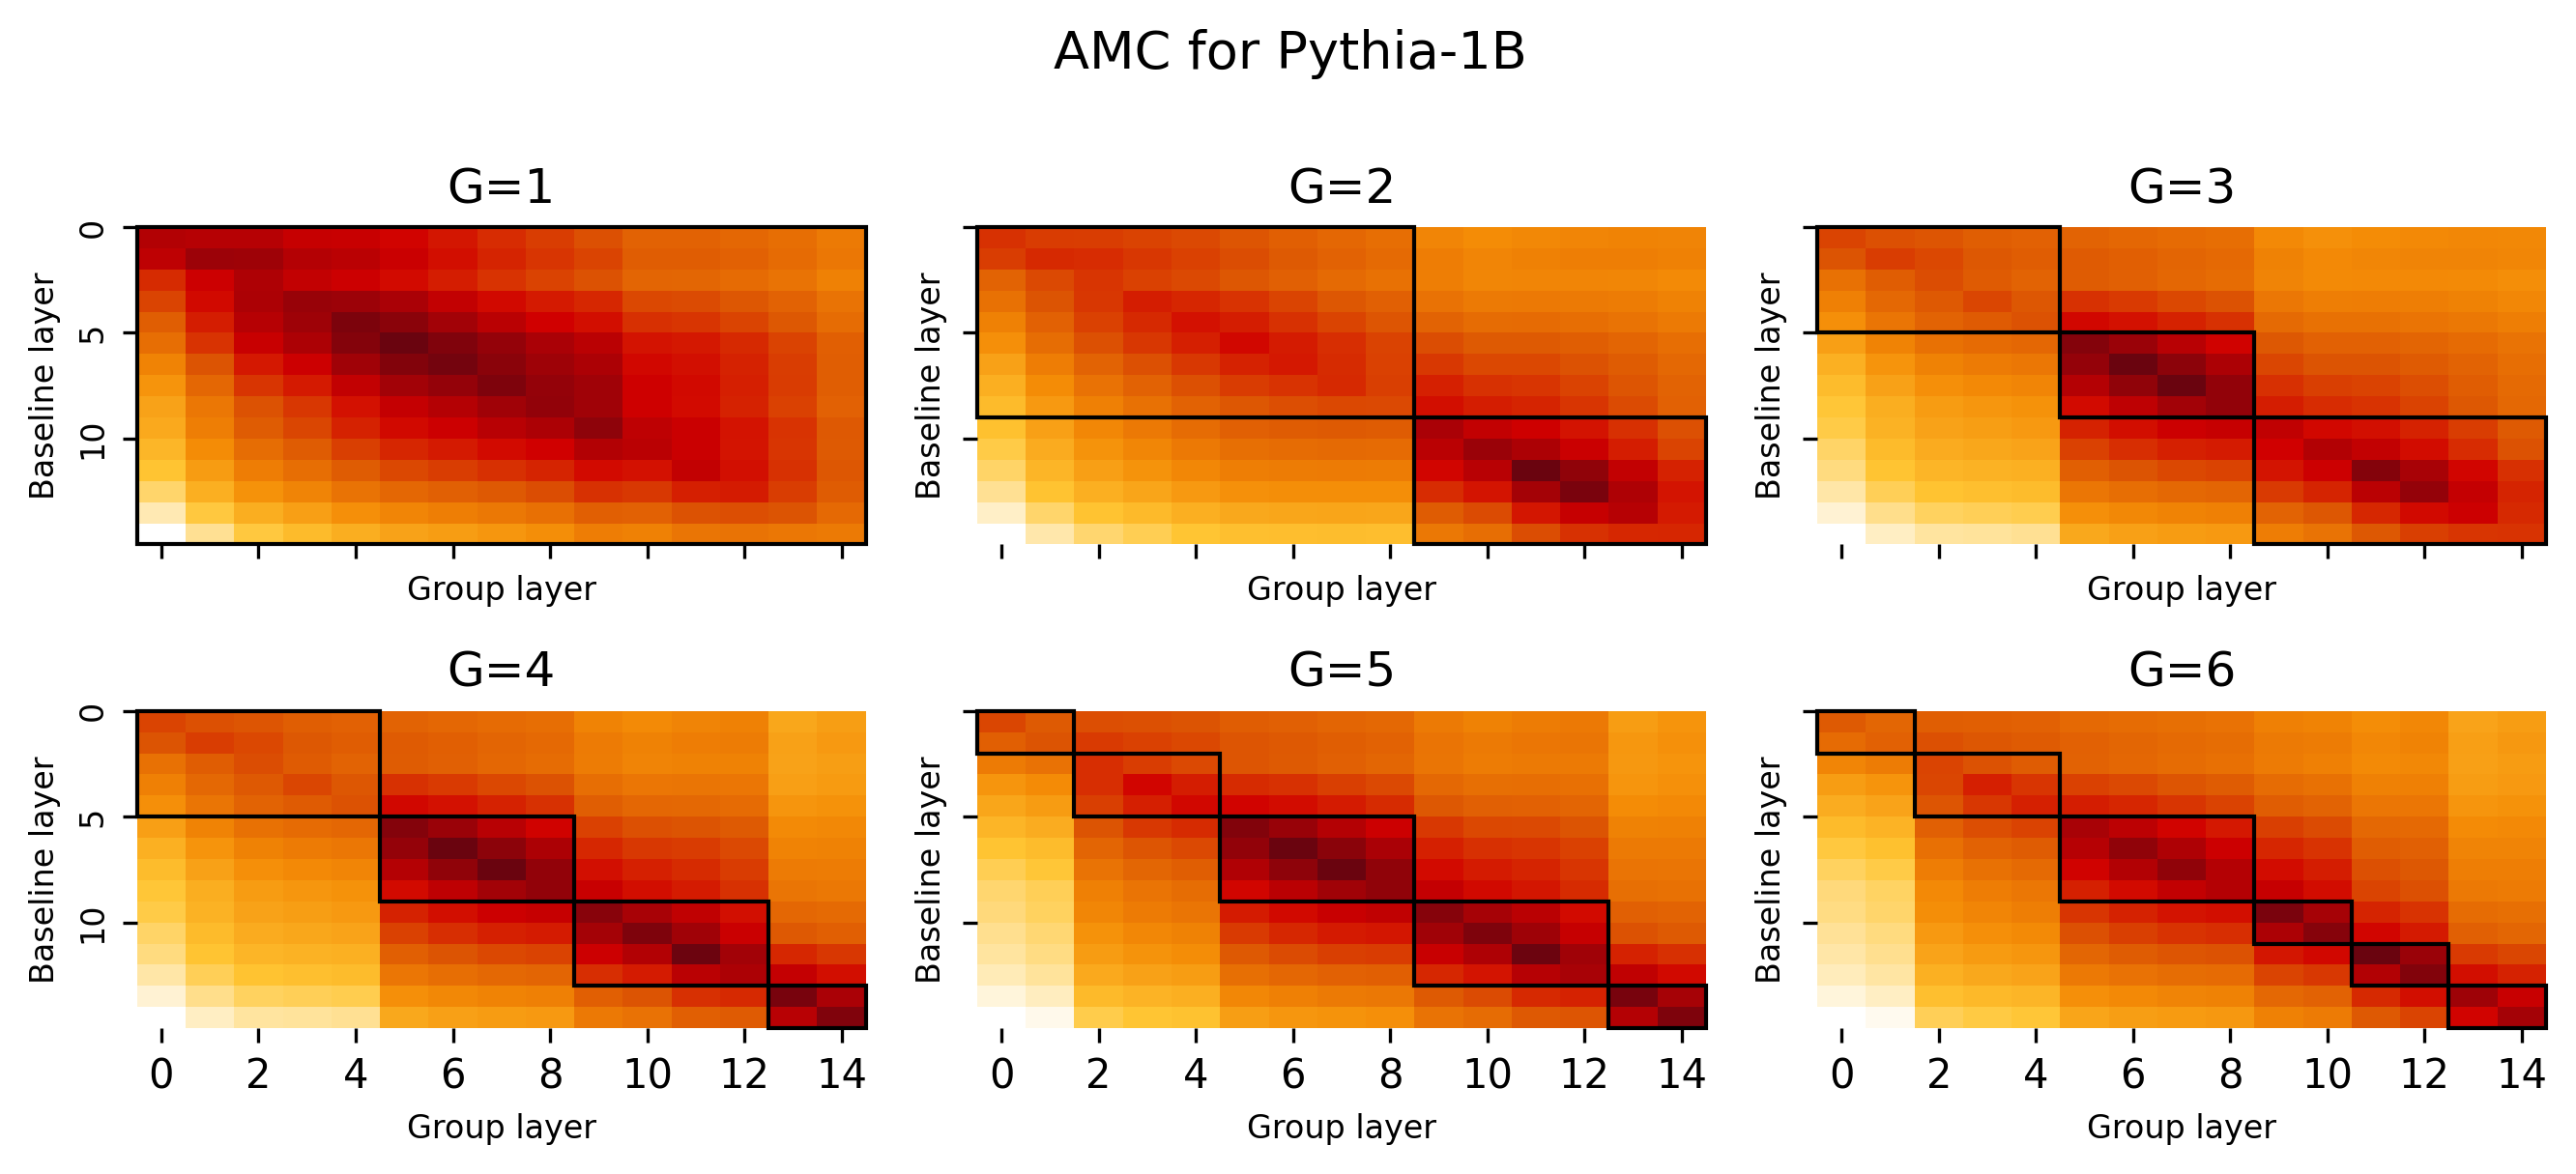

In [3]:
# Load the cluster map (assumed to be a dict with keys as K values, e.g., "3", "4", "5", etc.)
cluster_map = load_cluster_map(size)
cluster_map = {str(k): v for k, v in cluster_map.items() if int(k) <= g_hats[model_name]}

# Get a sorted list of K values (as strings) from the cluster map.
Ks = sorted(cluster_map.keys(), key=int)

# Define the color palette and create the colormap.
palette = ["#FFFFFF", "#FFC533", "#f48c06", "#DD5703", "#d00000", "#6A040F"]
cmap = LinearSegmentedColormap.from_list("paper", palette)

# Create a grid for subplots: 3 columns and enough rows.
ncols = 3
nrows = math.ceil(len(Ks) / ncols)
fig, axes = plt.subplots(
    nrows, ncols, figsize=(3 * ncols, 2 * nrows), sharex=True, sharey=True, dpi=300
)
axes = axes.flatten()  # simplify iterating over axes

# Loop over each K and plot its heatmap and cluster boundaries.
for ax, K in zip(axes, Ks):
    # Build the folder path and load the concordance matrix.
    concordance_folder = os.path.join(base_folder, K)
    concordance_matrix = np.load(os.path.join(concordance_folder, "concordance.npy"))

    # Get cluster labels for the current K.
    cluster_labels = cluster_map[K]

    # Compute the contiguous blocks in the ordering.
    unique_labels, inv = np.unique(cluster_labels, return_inverse=True)
    n = len(inv)
    blocks = []
    start = 0
    for i in range(1, n):
        if inv[i] != inv[i - 1]:
            blocks.append((start, i))
            start = i
    blocks.append((start, n))  # add the final block
    print(f"Blocks for K={K}: {blocks}")

    # Check if any cluster is composed of a single layer.
    has_single_layer = any((end - start) == 1 for start, end in blocks)
    # Adjust vmax accordingly: if there's a single-layer cluster, scale down vmax.
    if has_single_layer:
        vmax_val = concordance_matrix.max() * 0.3
    else:
        vmax_val = concordance_matrix.max()

    # Plot the heatmap with the adjusted vmax.
    sns.heatmap(concordance_matrix, cmap=cmap, ax=ax, cbar=False, vmax=vmax_val)
    ax.set_title("G={}".format(K))
    ax.set_xlabel("Group layer", fontsize=8)
    ax.set_ylabel("Baseline layer", fontsize=8)
    yticks = np.arange(0, concordance_matrix.shape[0], 5)
    yticks_labels = [str(i) for i in yticks]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks_labels, fontsize=8)

    # Add a border to the heatmap by customizing the axis spines.
    # for spine in ax.spines.values():
    #     spine.set_edgecolor("black")
    #     spine.set_linewidth(0)

    # Draw a square (a Rectangle with equal width and height) for each contiguous cluster block.
    for start, end in blocks:
        width = end - start
        rect = patches.Rectangle(
            (start, start),
            width,
            width,
            fill=False,
            edgecolor="black",
            lw=1,
            clip_on=False,
        )
        ax.add_patch(rect)

# Turn off any extra axes if there are more subplots than Ks.
for ax in axes[len(Ks) :]:
    ax.axis("off")
fig.suptitle(f"AMC for {model_name.title()}", fontsize=13, y=1.0)

plt.tight_layout()
os.makedirs("imgs", exist_ok=True)
plt.savefig(
    os.path.join("imgs", f"concordance_{model_name}_all.png"), bbox_inches="tight", dpi=300
)
plt.show()